# Exercise: Grid World Navigation
## AIAT 123 - Reinforcement Learning

## Learning Objectives

- Implement Q-learning algorithm
- Train agent in grid world
- Navigate to goal
- Apply to pathfinding

## Real-World Context

Train agent to navigate mazes, find optimal paths.

**Task**: Build Q-learning agent for grid navigation.

---

## Task 1: Grid World Environment (25 points)

Create grid world:
1. Define grid
2. Set start and goal
3. Define actions and rewards

## Exercise Brief

This exercise checks whether students can implement the full Q-learning loop themselves.

They must connect environment interaction, action selection, value updates, and learning progress into one coherent workflow.

Why this matters: Unit 2 is where RL stops being only conceptual and starts becoming algorithmic.

This exercise verifies that students can translate the lesson into runnable logic.

### If Python feels hard right now

- Run code cells **from top to bottom** the first time; later you can re-run one cell after you change it.
- In code cells, a line that starts with `# ` (hash + space) is a **hint for the very next line**—read the hint, then read the code under it.
- You do **not** need to memorize syntax. Follow the story: *what is stored*, *what gets printed*, and *what the plot is trying to show*.
- If something errors, read the last line of the red traceback first—it usually names the problem in plain language.


## Exercise Goal

Build a small grid-world Q-learning setup and explain why the learned values should
improve navigation toward the goal.


## Student Support Pack

Use this section before coding so you know what the exercise is testing conceptually.

### Key Terms
- Agent: the decision maker.
- Environment: the world it acts in.
- Reward: feedback signal.
- Return: long-term reward total.

### Quick Check
- What core RL idea does this notebook teach?
- Which output best reflects the main concept?
- How would you explain this topic in one minute?

### Common Mistakes
- Focusing on syntax before meaning.
- Reading outputs without connecting them to the concept.
- Missing how one step fits the whole RL loop.


### Step Guide

**What this cell does:** Import libraries and set small global constants for the lesson.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [1]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

# Load a library so you can use its ready-made functions and types below.
import numpy as np


# Class `GridWorld` (what it does): defines an object blueprint (attributes + methods); read the indented block to see each part.
class GridWorld:
    # Function `__init__` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self, size.
    def __init__(self, size=5):
        # Save a value in a name so the next lines can read it.
        self.size = size
        # Another assignment—same idea: store a value for the lines below.
        self.start = (0, 0)
        # Another assignment—same idea: store a value for the lines below.
        self.goal = (size - 1, size - 1)
        # Another assignment—same idea: store a value for the lines below.
        self.actions = [(-1, 0), (0, 1), (1, 0), (0, -1)]
        # Another assignment—same idea: store a value for the lines below.
        self.state = self.start

    # Function `reset` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self.
    def reset(self):
        # Save a value in a name so the next lines can read it.
        self.state = self.start
        # Send a value back to whoever called this function.
        return self.state_to_index(self.state)

    # Function `state_to_index` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self, state.
    def state_to_index(self, state):
        # Send a value back to whoever called this function.
        return state[0] * self.size + state[1]

    # Function `step` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self, action.
    def step(self, action):
        # Save a value in a name so the next lines can read it.
        dr, dc = self.actions[action]
        # Another assignment—same idea: store a value for the lines below.
        r = min(max(self.state[0] + dr, 0), self.size - 1)
        # Another assignment—same idea: store a value for the lines below.
        c = min(max(self.state[1] + dc, 0), self.size - 1)
        # Another assignment—same idea: store a value for the lines below.
        self.state = (r, c)
        # Unpack the one-step model output from transition(state, action).
        reward = 10 if self.state == self.goal else -1
        # Save a value in a name so the next lines can read it.
        done = self.state == self.goal
        # Send a value back to whoever called this function.
        return self.state_to_index(self.state), reward, done


# Save a value in a name so the next lines can read it.
env = GridWorld(size=5)
# Show text or numbers in the cell output area under the code.
print("Initial state index:", env.reset())


Initial state index: 0


## Task 2: Q-Learning Implementation (35 points)

Implement Q-learning:
1. Initialize Q-table
2. Update Q-values
3. Select actions

### Step Guide

**What this cell does:** Follow the printed section: "Updated Q-table shape:"

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [2]:
# Model definition: this class packages one core RL concept into a reusable object.
# Read its state, methods, and update rules together so the algorithm feels concrete.

# Class `QLearningAgent` (what it does): defines an object blueprint (attributes + methods); read the indented block to see each part.
class QLearningAgent:
    # Function `__init__` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self, n_states, n_actions, alpha, gamma, epsilon.
    def __init__(self, n_states, n_actions, alpha=0.1, gamma=0.95, epsilon=0.1):
        # Save a value in a name so the next lines can read it.
        self.q = np.zeros((n_states, n_actions))
        # Another assignment—same idea: store a value for the lines below.
        self.alpha = alpha
        # Another assignment—same idea: store a value for the lines below.
        self.gamma = gamma
        # Another assignment—same idea: store a value for the lines below.
        self.epsilon = epsilon
        # Another assignment—same idea: store a value for the lines below.
        self.n_actions = n_actions

    # Function `select_action` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self, state.
    def select_action(self, state):
        # If the condition is True, run the indented block under this line.
        if np.random.rand() < self.epsilon:
            # Send a value back to whoever called this function.
            return np.random.randint(self.n_actions)
        # Send a value back to whoever called this function.
        return int(np.argmax(self.q[state]))

    # Function `update` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self, state, action, reward, next_state.
    def update(self, state, action, reward, next_state):
        # Save a value in a name so the next lines can read it.
        best_next = np.max(self.q[next_state])
        # Another assignment—same idea: store a value for the lines below.
        self.q[state, action] += self.alpha * (
            # Execute: reward + self.gamma * best_next - self.q[state, action]
            reward + self.gamma * best_next - self.q[state, action]
        # Close the parentheses opened earlier (end this function call / grouping).
        )


# Save a value in a name so the next lines can read it.
agent = QLearningAgent(n_states=25, n_actions=4)
# Create or choose a variable used in the Bellman warm-up demo.
state = env.reset()
# Start a loop: repeat the indented block once per item in the sequence.
for _ in range(20):
    # Save a value in a name so the next lines can read it.
    action = agent.select_action(state)
    # Unpack the one-step model output from transition(state, action).
    next_state, reward, done = env.step(action)
    # Execute: agent.update(state, action, reward, next_state)
    agent.update(state, action, reward, next_state)
    # Create or choose a variable used in the Bellman warm-up demo.
    state = next_state
    # If the condition is True, run the indented block under this line.
    if done:
        # Stop the loop completely and continue after the loop block.
        break

# Show text or numbers in the cell output area under the code.
print("Updated Q-table shape:", agent.q.shape)
# Show text or numbers in the cell output area under the code.
print("Task prompt: train longer and explain how epsilon affects learning.")


Updated Q-table shape: (25, 4)
Task prompt: train longer and explain how epsilon affects learning.


## Task 3: Training and Evaluation (40 points)

Train agent and evaluate performance.

**Submission**: Complete notebook with trained agent.

**Grading**: 100 points total

## Reflection

Before submitting, explain:

- why the reward encourages reaching the goal quickly
- how epsilon affects exploration
- why Q-learning updates toward the best next action

### Step Guide

**What this cell does:** Run a worked scenario step by step; compare each print to the markdown theory.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


Average reward over last 50 episodes: 1.02
Greedy action at the start state: 1
Reminder: reward is -1 each move and +10 at the goal, so shorter successful paths score higher.


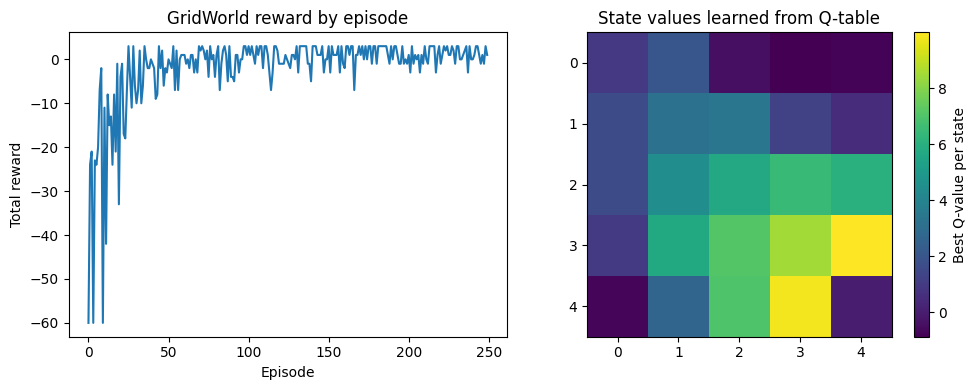

In [3]:
# Worked example: train the same GridWorld-style task that students build in the exercise.
# The goal is to make the feedback, the policy, and the reward shaping feel concrete.

# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt

# Use NumPy for fast numeric arrays and math on grids of numbers.
np.random.seed(42)

# Save a value in a name so the next lines can read it.
env = GridWorld(size=5)
# Another assignment—same idea: store a value for the lines below.
agent = QLearningAgent(n_states=25, n_actions=4, alpha=0.1, gamma=0.95, epsilon=0.2)

# Another assignment—same idea: store a value for the lines below.
episode_rewards = []
# Another assignment—same idea: store a value for the lines below.
episode_steps = []

# Start a loop: repeat the indented block once per item in the sequence.
for episode in range(250):
    # Create or choose a variable used in the Bellman warm-up demo.
    state = env.reset()
    # Save a value in a name so the next lines can read it.
    total_reward = 0

    # Start a loop: repeat the indented block once per item in the sequence.
    for step_idx in range(60):
        # Save a value in a name so the next lines can read it.
        action = agent.select_action(state)
        # Unpack the one-step model output from transition(state, action).
        next_state, reward, done = env.step(action)
        # Execute: agent.update(state, action, reward, next_state)
        agent.update(state, action, reward, next_state)
        # Create or choose a variable used in the Bellman warm-up demo.
        state = next_state
        # Save a value in a name so the next lines can read it.
        total_reward += reward

        # If the condition is True, run the indented block under this line.
        if done:
            # Add one new item to the end of a list (the list grows in place).
            episode_steps.append(step_idx + 1)
            # Stop the loop completely and continue after the loop block.
            break
    # Else: run this block when none of the if/elif tests above matched.
    else:
        # Add one new item to the end of a list (the list grows in place).
        episode_steps.append(60)

    # Add one new item to the end of a list (the list grows in place).
    episode_rewards.append(total_reward)

# Save a value in a name so the next lines can read it.
avg_last_50 = np.mean(episode_rewards[-50:])
# Show text or numbers in the cell output area under the code.
print("Average reward over last 50 episodes:", round(avg_last_50, 2))
# Show text or numbers in the cell output area under the code.
print("Greedy action at the start state:", int(np.argmax(agent.q[env.reset()])))
# Show text or numbers in the cell output area under the code.
print("Reminder: reward is -1 each move and +10 at the goal, so shorter successful paths score higher.")

# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.figure(figsize=(10, 4))
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.subplot(1, 2, 1)
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.plot(episode_rewards)
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.title("GridWorld reward by episode")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.xlabel("Episode")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.ylabel("Total reward")

# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.subplot(1, 2, 2)
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.imshow(agent.q.max(axis=1).reshape(env.size, env.size), cmap="viridis")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.colorbar(label="Best Q-value per state")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.title("State values learned from Q-table")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.tight_layout()
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.show()


In [4]:
# References (shown with Markdown inside a Python cell — avoids SyntaxError if a Markdown block is run as code.)
from IPython.display import Markdown, display

display(Markdown(r"""## 📚 References & Further Reading

### Books
- Sutton & Barto — [Reinforcement Learning: An Introduction](http://incompleteideas.net/book/the-book-2nd.html) (free online, the RL bible)

### Papers
- Mnih et al. (2015) — [Human-level control through deep RL (DQN)](https://www.nature.com/articles/nature14236)
- Silver et al. (2016) — [AlphaGo](https://www.nature.com/articles/nature16961)

### State-of-the-art OpenAI Five beat world champions in Dota2; AlphaFold uses RL-like optimization for protein folding.
"""))


## 📚 References & Further Reading

### Books
- Sutton & Barto — [Reinforcement Learning: An Introduction](http://incompleteideas.net/book/the-book-2nd.html) (free online, the RL bible)

### Papers
- Mnih et al. (2015) — [Human-level control through deep RL (DQN)](https://www.nature.com/articles/nature14236)
- Silver et al. (2016) — [AlphaGo](https://www.nature.com/articles/nature16961)

### State-of-the-art OpenAI Five beat world champions in Dota2; AlphaFold uses RL-like optimization for protein folding.


### Step Guide

**What this cell does:** Try to auto-plot lesson numbers already in memory (optional recap charts).

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Either one or more plots, or a short message that nothing was auto-plotted.

**If you feel lost:** Re-run the main lesson cells so numeric variables exist, then try this recap again.


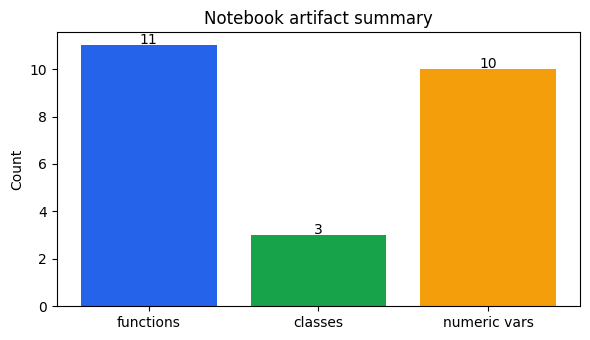

In [5]:
# Visual recap: turn the lesson's numeric artifacts into quick charts.
# The goal is to help students see patterns that are harder to catch from raw printed output alone.
# Load a library so you can use its ready-made functions and types below.
import numbers
# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt

# Function `_is_number` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _is_number(value):
    # Send a value back to whoever called this function.
    return isinstance(value, (int, float, np.integer, np.floating)) and not isinstance(value, bool)

# Function `_as_numeric_dict` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _as_numeric_dict(value):
    # If the condition is True, run the indented block under this line.
    if not isinstance(value, dict) or not value or len(value) > 12:
        # Send a value back to whoever called this function.
        return None
    # Collect numeric dict values after validation for plotting.
    converted = []
    # Start a loop: repeat the indented block once per item in the sequence.
    for item in value.values():
        # If the condition is True, run the indented block under this line.
        if not _is_number(item):
            # Send a value back to whoever called this function.
            return None
        # Add one new item to the end of a list (the list grows in place).
        converted.append(float(item))
    # Send a value back to whoever called this function.
    return [str(key) for key in value.keys()], np.asarray(converted, dtype=float)

# Function `_as_numeric_array` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value, dims.
def _as_numeric_array(value, dims):
    # Try/except/finally: structured error handling around risky operations.
    try:
        # Temporary ndarray after coercion attempt inside _as_numeric_array().
        array = np.asarray(value, dtype=float)
    # Try/except/finally: structured error handling around risky operations.
    except Exception:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if array.ndim != dims:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 1 and not (2 <= array.size <= 200):
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 2 and array.size > 400:
        # Send a value back to whoever called this function.
        return None
    # Send a value back to whoever called this function.
    return array

# Preferred global names to try first when auto-picking lesson plots.
priority_names = [
    # Execute: "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    # Execute: "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores …
    "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores"
# Execute: ]
]

# Names that are never lesson metrics (imports / plotting handles).
skip_names = {"np", "plt", "numbers", "math", "Figure", "fig"}
# Save a value in a name so the next lines can read it.
candidates = []
# Track which names were already visited to avoid duplicates.
seen = set()
# Ordered list of global names to scan for plottable numeric artifacts.
search_space = priority_names + sorted(name for name in globals() if not name.startswith("_"))

# Start a loop: repeat the indented block once per item in the sequence.
for name in search_space:
    # If the condition is True, run the indented block under this line.
    if name in seen or name not in globals() or name in skip_names:
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue
    # Execute: seen.add(name)
    seen.add(name)
    # The runtime object bound to that global name.
    value = globals()[name]

    # Try to interpret a global variable as a plottable payload (or None if not).
    dict_payload = _as_numeric_dict(value)
    # If the condition is True, run the indented block under this line.
    if dict_payload is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("dict", name, dict_payload))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_2d = _as_numeric_array(value, 2)
    # If the condition is True, run the indented block under this line.
    if array_2d is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("heatmap", name, array_2d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_1d = _as_numeric_array(value, 1)
    # If the condition is True, run the indented block under this line.
    if array_1d is not None:
        # Append one value to a list (mutates the list in place).
        # Skip misleading line plots for last-step env vectors (not time series).
        # If the condition is True, run the indented block under this line.
        if name in {"obs", "next_obs", "state", "action"} and array_1d.size <= 16:
            # Skip to the next lap of the loop (ignore the rest of this lap).
            continue
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("line", name, array_1d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break

# If the condition is True, run the indented block under this line.
if not candidates:
    # Build a small dict used only for the fallback summary bar chart.
    summary = {
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "functions": sum(callable(value) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "classes": sum(isinstance(value, type) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "numeric vars": sum(_is_number(value) for value in globals().values()),
    # Part of a dict/set literal layout (syntax grouping).
    }
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, ax = plt.subplots(figsize=(6, 3.5))
    # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
    ax.bar(summary.keys(), summary.values(), color=["#2563eb", "#16a34a", "#f59e0b"])
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_title("Notebook artifact summary")
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_ylabel("Count")
    # Start a loop: repeat the indented block once per item in the sequence.
    for idx, value in enumerate(summary.values()):
        # Same plot panel as the line above—one more small plotting tweak.
        ax.text(idx, value + 0.05, str(value), ha="center")
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()
# Else: run this block when none of the if/elif tests above matched.
else:
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, axes = plt.subplots(1, len(candidates), figsize=(5 * len(candidates), 3.8))
    # If the condition is True, run the indented block under this line.
    if len(candidates) == 1:
        # Save a value in a name so the next lines can read it.
        axes = [axes]

    # Start a loop: repeat the indented block once per item in the sequence.
    for ax, (kind, name, payload) in zip(axes, candidates):
        # If the condition is True, run the indented block under this line.
        if kind == "dict":
            # Unpack plotting payload for dict bar charts (keys vs numeric values).
            labels, values = payload
            # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
            ax.bar(range(len(values)), values, color="#2563eb")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticks(range(len(values)))
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticklabels(labels, rotation=45, ha="right")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (dict)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
        # Else-if: only checked when the earlier if/elif tests were False.
        elif kind == "line":
            # Same plot panel as the line above—one more small plotting tweak.
            ax.plot(payload, marker="o", linewidth=2, color="#16a34a")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (series)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xlabel("Index")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
        # Else: run this block when none of the if/elif tests above matched.
        else:
            # Image handle returned by imshow for attaching a colorbar.
            image = ax.imshow(payload, aspect="auto", cmap="viridis")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (heatmap)")
            # Change something about the whole figure (not just one small subplot).
            fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()


## Closing Takeaway

**Teaching takeaway:** This exercise checks whether students can apply classical RL updates independently rather than only recognizing them in notes.

**If students remember one idea:** Real understanding appears when a student can explain why an update changed, not just compute it mechanically.

**Quick check before moving on:**
- Can you justify each update in your own words?
- Can you explain how your exploration choice influenced the learned values?

**Bridge to the next step:** After this exercise, students are ready to move from tabular methods toward deep RL representations.

**For weaker coders:** After you run the important cells, write one sentence: *what number or plot changed, and does that match what the lesson said should happen?* If not, re-read only the `#` hint lines in that cell—not every line of Python.


## Motion recap (optional)

**Why this cell exists:** many RL ideas are easiest to sanity-check when you can **watch time unfold** — a state changes because an action was taken, then a reward signal arrives.

**FrozenLake here is a shared toy picture** (not the “whole story” of every method in this notebook):
- Treat it as a **concrete instance** of the vocabulary you already used: **state** = which tile, **action** = move direction, **reward** = goal / hole / step, **episode** = from start until stop.

**Map this picture to your lesson (pick what fits):**
- **MDPs / value iteration / DP ideas:** ask what a “good tile” should be worth *on the way* to the goal, and what a hole implies for long-horizon returns.
- **Policy evaluation / Monte Carlo / TD / Q-learning / SARSA:** relate the moves you see to **estimated values or Q(s,a)** and to the **backup** idea you implemented above.
- **Exploration vs exploitation / UCB / tuning ε:** random moves are a deliberate exaggeration — compare **wide wandering** vs a mostly greedy path, and connect that to the exploration rule you studied in this unit.
- **Deep RL / training at scale:** use this as a **minimal loop** (observe → act → reward → learn) while remembering real applications change the **observation**, not the basic cycle.

The policy in the next cell is **random on purpose** so the GIF/slider foreground **transitions**, not a claim that this notebook’s full method is already optimal on this map.

### Why the agent may never reach the gift (goal tile `G`)
The code uses **uniform random actions**. That is **not** trying to “solve” FrozenLake or show a hero run to the goal. The point is to show **typical transitions**: safe tiles, edges, sometimes holes, sometimes lucky progress. **Not reaching `G` is expected** and still useful — read the **sequence** (state → action → next state → reward), not “did it win in 10 seconds?”

### Quick student check (about 60 seconds)
- Scroll to **one core code cell above** that carries the main idea of this lesson (policy update, backup, ε-rule, training step, …).
- In one sentence, name **one symbol or variable** from that cell that lines up with **state**, **action**, or **reward** in the FrozenLake frames.
- If you cannot name a match yet, re-run the main lesson cells once, then return here — the GIF is a **mirror** for vocabulary, not a replacement for the definitions.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


Motion recap | return=0.0 | frames=4 | term=True | trunc=False


objc[77886]: Class SDL_RumbleMotor is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x114374138) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1148709c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[77886]: Class SDL_RumbleContext is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x114374188) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x114870a18). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[77886]: Class SDLApplication is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x114373c88) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x114870a68). T

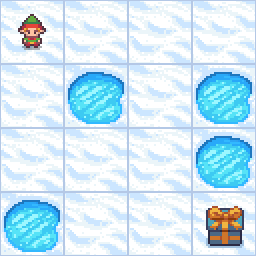

In [6]:
# MOTION_RECAP_COURSE09 — shared optional visual (FrozenLake GIF + step slider).

%pip install pillow ipywidgets -q

import pathlib
import sys

import numpy as np

for _d in [pathlib.Path.cwd().resolve(), *pathlib.Path.cwd().resolve().parents]:
    if (_d / "course09_step_viz.py").exists():
        _course09 = _d
        break
else:
    raise FileNotFoundError(
        "Could not find course09_step_viz.py — open this notebook from inside Course 09 "
        "(normal Jupyter / Cursor layout) so parent folders include the Course 09 root."
    )

if str(_course09) not in sys.path:
    sys.path.insert(0, str(_course09))

import gymnasium as gym
import course09_step_viz as cs9viz


def _random_policy(obs, step):
    return int(np.random.randint(0, 4))


env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False, render_mode="rgb_array")
frames, total_r, terminated, truncated = cs9viz.collect_rollout_frames(
    env, _random_policy, max_steps=48, seed=42
)
env.close()
print(
    f"Motion recap | return={total_r:.1f} | frames={len(frames)} | term={terminated} | trunc={truncated}"
)
cs9viz.display_gif(frames, duration_ms=110)
cs9viz.display_step_slider(frames, title="FrozenLake — timestep")


## Did you understand? (about 2 minutes)

<!-- STUDENT_SELF_CHECK_COURSE09 -->

Answer **without scrolling** first. Then scroll only to compare with the notebook.

1. **One sentence:** What is the *single main idea* you are supposed to carry to the next lesson?
2. **Trace one step:** Pick one moment from this notebook (a number you printed, a plot, a table, or a GIF/slider frame). Write **state → action → reward → next state** in your own words — even if your “state” is a vector or a tile index.
3. **One honest confusion:** Write one question you still have. That question is what you should bring to class, study group, or office hours.

**If any answer is blank:** run the notebook again from the top **slowly** (run one cell → read the output → only then run the next).

**Remember:** a clean run means the code worked — it does **not** automatically mean every idea clicked. Confusion is normal until you can do steps 1–2 in plain language.
